In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("../data/processed/unsw_nb15_processed.csv")

In [3]:
df['attack_cat'].value_counts()

attack_cat
 0.315927    8775
-1.543198     840
-2.162907     156
-6.500867      68
-2.782616      62
-5.881158      51
-7.120576      15
-4.641741      10
-0.923490       8
-5.261450       7
-4.022033       4
-3.402324       3
-0.303781       1
Name: count, dtype: int64

In [4]:
df['attack_cat'] = df ['attack_cat'].fillna("Normal")
df['attack_cat'] = df['attack_cat'].astype(str)

In [5]:
le = LabelEncoder()
df['attack_cat_encoded'] = le.fit_transform(df['attack_cat'])

target_names = [str(cls) for cls in le.classes_]

In [6]:
attack_mapping = dict(zip(le.classes_, le.transform(df['attack_cat'])))

In [7]:
X = df.drop(columns=['label', 'attack_cat', 'attack_cat_encoded'])
y = df['attack_cat_encoded']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [9]:
rf_multi = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [10]:
y_pred = rf_multi.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    labels=list(range(len(le.classes_))),
    target_names=le.classes_,
    zero_division=0
))

                     precision    recall  f1-score   support

-0.3037811528203318       0.00      0.00      0.00         0
-0.9234897469050566       1.00      1.00      1.00         1
-1.5431983409897811       0.99      0.97      0.98       159
 -2.162906935074506       0.63      0.76      0.69        34
-2.7826155291592305       0.20      0.22      0.21         9
 -3.402324123243955       0.00      0.00      0.00         1
  -4.02203271732868       0.00      0.00      0.00         0
 -4.641741311413405       0.00      0.00      0.00         3
  -5.26144990549813       0.00      0.00      0.00         3
 -5.881158499582854       0.83      0.50      0.62        10
 -6.500867093667579       0.50      0.23      0.32        13
 -7.120575687752304       1.00      0.33      0.50         3
 0.3159274412643928       0.99      1.00      0.99      1764

           accuracy                           0.98      2000
          macro avg       0.47      0.39      0.41      2000
       weighted avg   

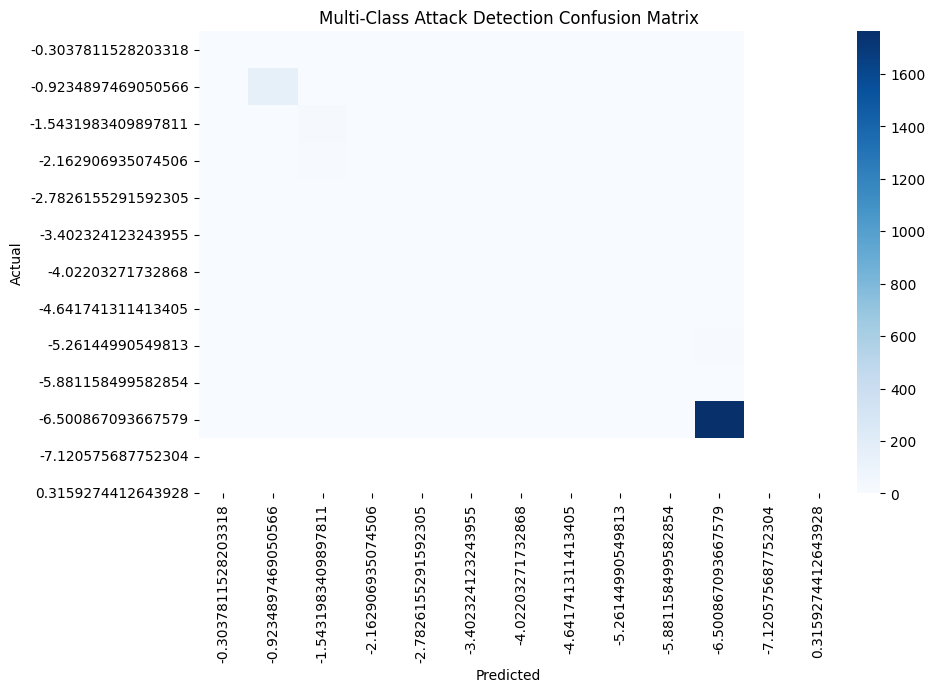

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(
    cm,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    annot=False,
    cmap="Blues"
)

plt.title("Multi-Class Attack Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
def predict_attack_type(event):
    pred = rf_multi.predict(event.values.reshape(1, -1))[0]
    return le.inverse_transform([pred])[0]

In [13]:
sample_event = X_test.iloc[10]
print("Predicted Attack Type:", predict_attack_type(sample_event))

Predicted Attack Type: 0.3159274412643928


/home/uzxn/AI-SOC/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [14]:
import joblib

joblib.dump(rf_multi, "../models/random_forest_multiclass.pkl")
joblib.dump(le, "../models/attack_label_encoder.pkl")

['../models/attack_label_encoder.pkl']